<ipython-input-3-0325f9cd1650>:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('city_temperature.csv')
<ipython-input-3-0325f9cd1650>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0410
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0033
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0028
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0024
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0023
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0022
Epoch 7/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0022
Epoch 8/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0022
Epoch 9/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0020
Epoch 10/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0021
Epoch 11/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0021
Epoch 12/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0021
Epoch 13/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0022
Epoch 14/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0021
Epoch 15/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - lo

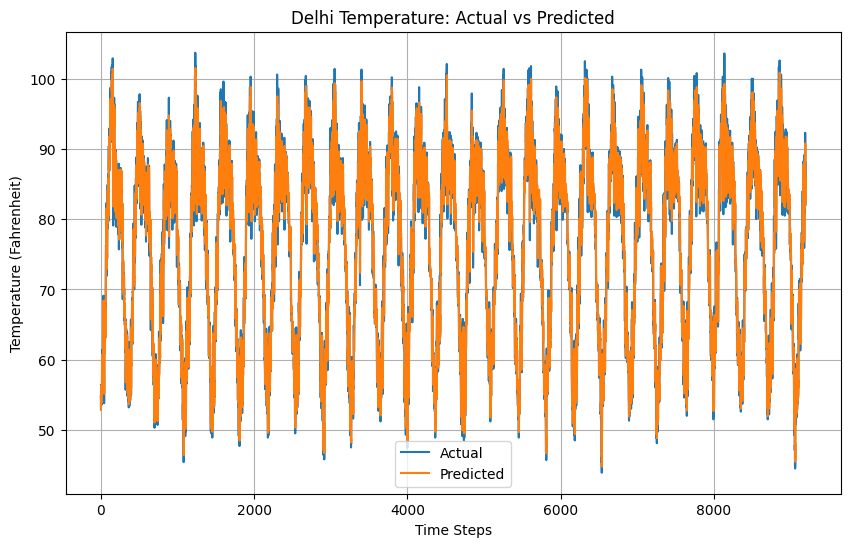

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv('city_temperature.csv')

# Filter for Delhi and valid temperature values
df = df[(df['City'] == 'Delhi') & (df['AvgTemperature'] != -99)]

# Sort by date
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df = df.sort_values('Date')

# Use only 'AvgTemperature' column
data = df['AvgTemperature'].values.reshape(-1, 1)

# Normalize the temperature data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(scaled_data, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Define LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X, y, epochs=20, batch_size=16)

# Predict next day's temperature
last_seq = scaled_data[-seq_length:].reshape(1, seq_length, 1)
predicted_scaled = model.predict(last_seq)
predicted_temp = scaler.inverse_transform(predicted_scaled)
print("Predicted Next Temperature in Delhi:", predicted_temp[0][0])

# Optional: Plot training set predictions
predicted_train = model.predict(X)
predicted_train_rescaled = scaler.inverse_transform(predicted_train)
actual_train_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.plot(actual_train_rescaled, label='Actual')
plt.plot(predicted_train_rescaled, label='Predicted')
plt.title('Delhi Temperature: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (Fahrenheit)')
plt.legend()
plt.grid(True)
plt.show()
